# ESC-50: exploring the dataset

[ESC-50](https://github.com/karolpiczak/ESC-50) (Piczak, 2015) has 2,000 environmental sound clips of 5 s
in 50 classes, recorded by many people with many microphones (taken from Freesound).

Before training anything, this notebook looks at the data: how it is organized, what it sounds like,
and what could mislead a model.

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from audiolab.analysis import compute_spectrogram
from audiolab.esc50 import GROUPS, load_clip, load_metadata

ROOT = Path("../data/ESC-50")    # unzipped from https://github.com/karolpiczak/ESC-50
GROUP_COLORS = dict(zip(GROUPS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))

## 1. Metadata

One row per clip. `src_file` is the Freesound recording the clip was cut from, and `take`
(A, B, C...) tells apart several clips cut from the same recording.

In [2]:
meta = load_metadata(ROOT)
print(meta.shape)
meta.head()

(2000, 8)


,filename,fold,target,category,esc10,src_file,take,group
0,1-100032-A-0.wav,1,0,dog,True,100032,A,animals
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,natural
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A,domestic
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B,domestic
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A,natural


## 2. Classes, groups and folds

In [3]:
for group, classes in meta.sort_values("target").groupby("group", sort=False).category.unique().items():
    print(f"{group:9s}", ", ".join(classes))

counts = pd.crosstab(meta.category, meta.fold)
print(f"\nClips per class and fold: min {counts.values.min()}, max {counts.values.max()}")

animals   dog, rooster, pig, cow, frog, cat, hen, insects, sheep, crow
natural   rain, sea_waves, crackling_fire, crickets, chirping_birds, water_drops, wind, pouring_water, toilet_flush, thunderstorm
human     crying_baby, sneezing, clapping, breathing, coughing, footsteps, laughing, brushing_teeth, snoring, drinking_sipping
domestic  door_wood_knock, mouse_click, keyboard_typing, door_wood_creaks, can_opening, washing_machine, vacuum_cleaner, clock_alarm, clock_tick, glass_breaking
urban     helicopter, chainsaw, siren, car_horn, engine, train, church_bells, airplane, fireworks, hand_saw

Clips per class and fold: min 8, max 8


Perfectly balanced: 40 clips per class, 8 in each fold. Accuracy is therefore a fair metric
(no class dominates), and chance level is 1/50 = 2%.

## 3. Clips that share a recording

A clip is what the microphone picked up: $y(t) = x(t) * h(t) + n(t)$, the sound source $x$
filtered by the channel $h$ (microphone, room) plus background noise $n$. Clips cut from the
same recording share $h$ and $n$, a fingerprint of the recording. If some of them were in the
training set and others in the test set, a model could score well by recognizing the fingerprint
instead of the sound. That is why the official folds keep them together.

1524 original recordings for 2000 clips
40% of the clips share their recording with at least one other clip


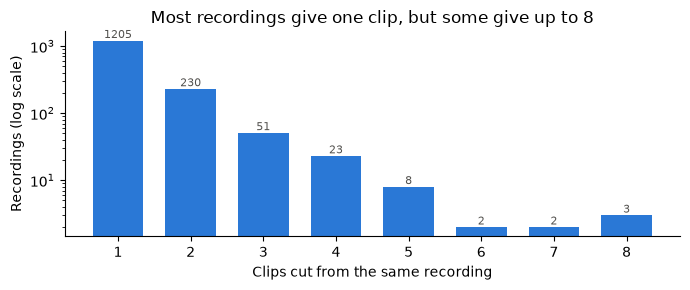

In [4]:
clips_per_recording = meta.groupby("src_file").size()
shares = meta.src_file.map(clips_per_recording) > 1
print(f"{meta.src_file.nunique()} original recordings for {len(meta)} clips")
print(f"{shares.mean():.0%} of the clips share their recording with at least one other clip")

dist = clips_per_recording.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(dist.index, dist.values, color="#2a78d6", width=0.7)
ax.set_yscale("log")
ax.set_xlabel("Clips cut from the same recording")
ax.set_ylabel("Recordings (log scale)")
ax.set_title("Most recordings give one clip, but some give up to 8")
for x, v in zip(dist.index, dist.values):
    ax.annotate(str(v), (x, v), ha="center", va="bottom", fontsize=8, color="#52514e")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Does any recording span several folds?

In [5]:
folds_per_recording = meta.groupby("src_file").fold.nunique()
spanning = folds_per_recording[folds_per_recording > 1].index
meta[meta.src_file.isin(spanning)].sort_values(["src_file", "fold"])[["filename", "fold", "category", "src_file"]]

,filename,fold,category,src_file
546,2-131943-A-38.wav,2,clock_tick,131943
908,3-131943-A-37.wav,3,clock_alarm,131943
551,2-134049-A-6.wav,2,hen,134049
915,3-134049-A-1.wav,3,rooster,134049
1543,4-209698-A-37.wav,4,clock_alarm,209698
1785,5-209698-A-38.wav,5,clock_tick,209698
1575,4-234879-A-6.wav,4,hen,234879
1888,5-234879-A-1.wav,5,rooster,234879
1889,5-234879-B-1.wav,5,rooster,234879


Only 4, and each one contains **two different classes** (clock tick + clock alarm, hen + rooster).
Within a class, the rule holds. These are also pairs a model will likely confuse.

## 4. Listening and looking: one clip per group

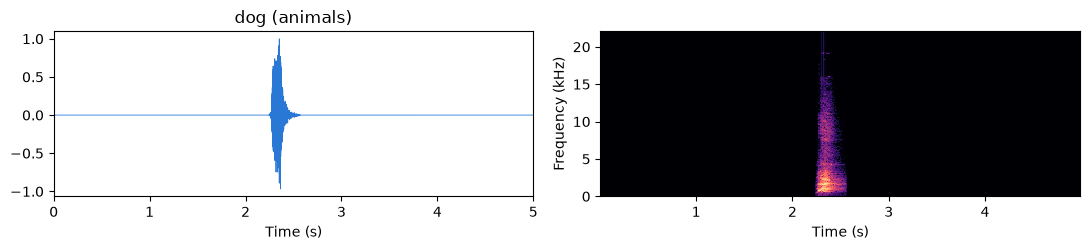

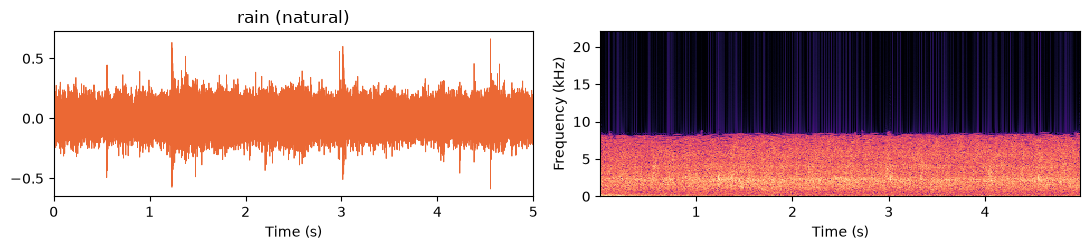

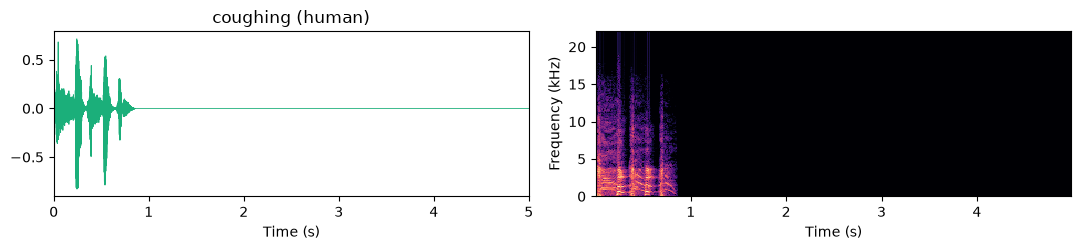

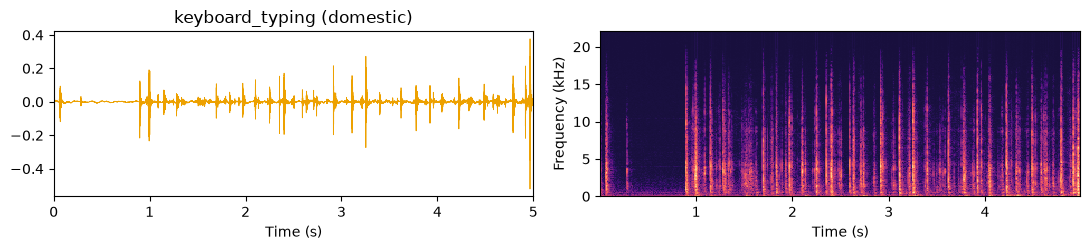

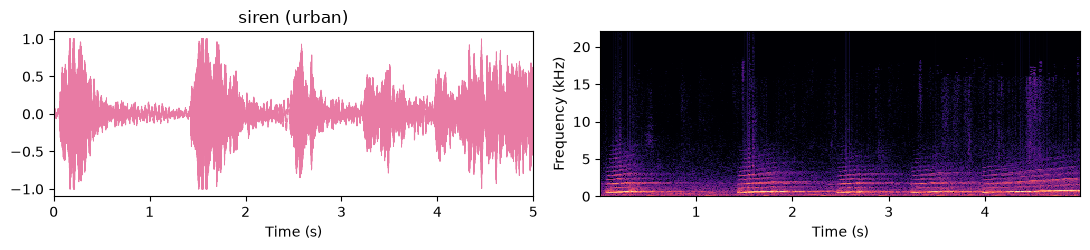

In [6]:
def show_clip(filename):
    row = meta.set_index("filename").loc[filename]
    y, fs = load_clip(ROOT, filename)
    t = np.arange(len(y)) / fs
    f, tt, S_dB = compute_spectrogram(y, fs)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 2.6))
    ax1.plot(t, y, color=GROUP_COLORS[row.group], linewidth=0.6)
    ax1.set_xlim(0, 5)
    ax1.set_xlabel("Time (s)")
    ax1.set_title(f"{row.category} ({row.group})")
    ax2.pcolormesh(tt, f / 1000, S_dB, cmap="magma", shading="auto", vmin=S_dB.max() - 80)
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Frequency (kHz)")
    plt.tight_layout()
    plt.show()
    display(Audio(y, rate=fs))

for category in ["dog", "rain", "coughing", "keyboard_typing", "siren"]:
    show_clip(meta[meta.category == category].filename.iloc[0])

## 5. Digital silence padding

Clips shorter than 5 s were padded with exact zeros. How much, and does it depend on the class?

In [7]:
def zero_fraction(filename):
    y, _ = load_clip(ROOT, filename)
    return np.mean(y == 0)

meta["zero_frac"] = [zero_fraction(fn) for fn in meta.filename]    # loads all 2,000 clips
print(f"{(meta.zero_frac > 0.1).mean():.0%} of the clips are more than 10% digital silence")
print(f"{(meta.zero_frac > 0.5).mean():.0%} are more than half silence")

20% of the clips are more than 10% digital silence
11% are more than half silence


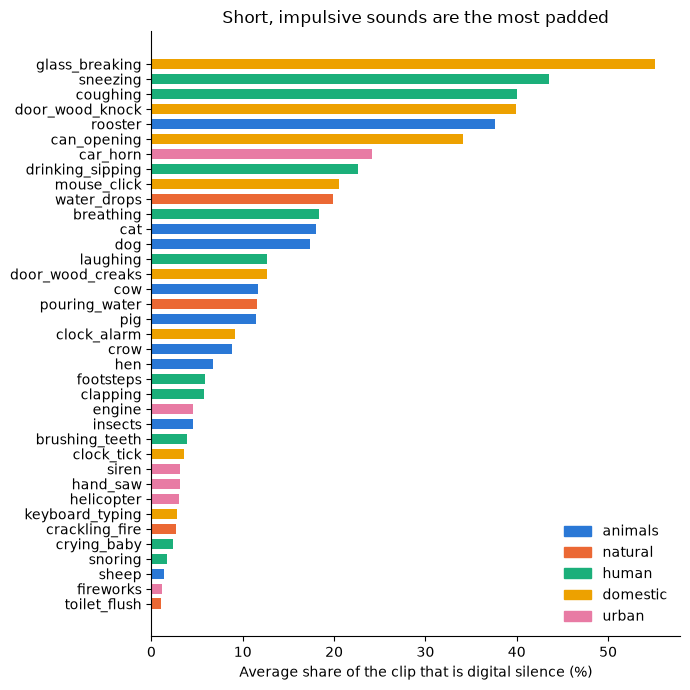

13 classes (continuous sounds: rain, wind, train...) have almost no padding


In [8]:
per_class = meta.groupby(["category", "group"]).zero_frac.mean().reset_index().sort_values("zero_frac")
per_class = per_class[per_class.zero_frac > 0.01]

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(per_class.category, per_class.zero_frac * 100, height=0.7,
        color=[GROUP_COLORS[g] for g in per_class.group])
ax.set_xlabel("Average share of the clip that is digital silence (%)")
ax.set_title("Short, impulsive sounds are the most padded")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=c) for c in GROUP_COLORS.values()],
          labels=GROUPS, loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()
print(f"{50 - len(per_class)} classes (continuous sounds: rain, wind, train...) have almost no padding")

The padding tells the class apart: lots of silence means an impulsive sound (glass breaking,
sneezing, coughing, a door knock), none means a continuous one. A model can learn to use it, but it
is an artifact of how the dataset was built: a real microphone never outputs exact zeros, it
always picks up some background noise.

## Takeaways

- **Balanced**: 8 clips per class per fold, chance level 2%. Accuracy is a fair metric.
- **Use the official folds**: 40% of the clips share their recording with others. Random splits would leak.
- **Beware of digital silence**: it is correlated with the class and absent in the real world.
  This matters for the features (MFCC averaged over silent frames) and for the live demo.